In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from preprocessing.cleaning import (
    normalize_nomenclatures_stock_report,
)


import openpyxl
import pandas as pd
from openpyxl.styles import PatternFill


from readers.loaders import preprocess_stock_report

    
def run_full_pipeline(
    stock_path: str
) -> pd.DataFrame | None:
    """
    Полный ETL-пайплайн: загрузка → нормализация → группировка → агрегация.
    """
    df2 = preprocess_stock_report(stock_path)
    df2 = normalize_nomenclatures_stock_report(df2)

df = run_full_pipeline(r'C:\Users\a.vorona\Desktop\Forecast\data\raw\Остатки и обороты_22_04_2026.xlsx')

c:\Users\a.vorona\Desktop\Forecast\preprocessing\cleaning.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ].str.contains(


[]


- Диаграмму по документ движение регистратор
- Диаграмму по наличию контрагента в расходе и неналичию
- Диаграмма по контрагентам своим и внутренним

In [37]:
s = df1['Документ движения (Регистратор)']

mask = s.str.strip().str.startswith(
    ('Возврат товаров', 'Приходный ордер', "Расходный ордер на", "Реализация товаров и услуг", "Списание товаров в ремонт" ,'Поступление товаров и' ,"Функционал заявки на", "Оприходование товаров", "Перемещение товаров", "Комплектация номенклатуры", "Требование-накладная", "Корректировка записей", "Списание товаров", "Передача материалов в"),
    na=False
)

df1[s.notna() & ~mask]

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток


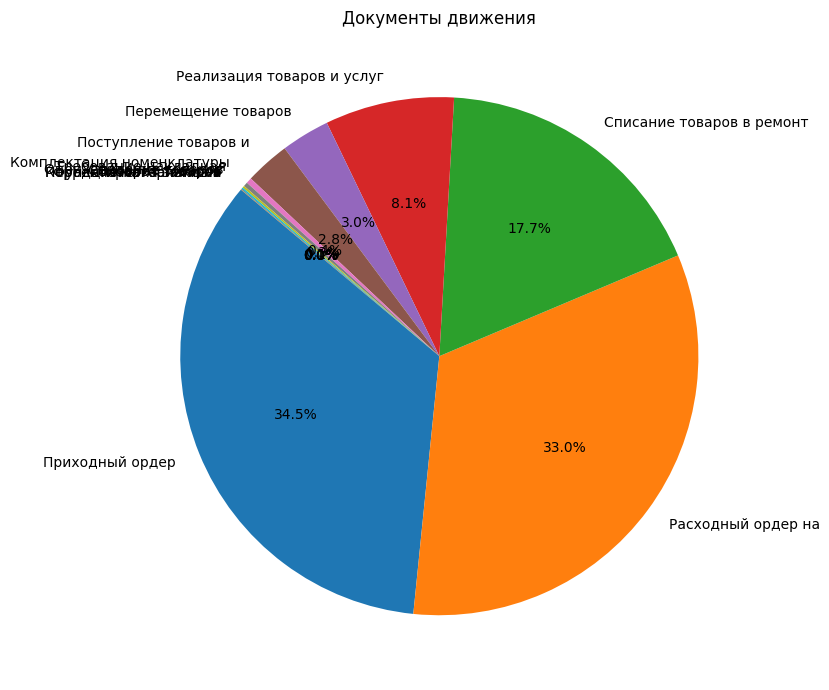

In [42]:
import matplotlib.pyplot as plt

s = df1['Документ движения (Регистратор)']

mask = s.str.strip().str.startswith(
    ('Возврат товаров', 'Приходный ордер', "Расходный ордер на", "Реализация товаров и услуг",
     "Списание товаров в ремонт", 'Поступление товаров и', "Функционал заявки на",
     "Оприходование товаров", "Перемещение товаров", "Комплектация номенклатуры",
     "Требование-накладная", "Корректировка записей", "Списание товаров",
     "Передача материалов в"),
    na=False
)

prefixes = [
    'Возврат товаров', 'Приходный ордер', 'Расходный ордер на', 'Реализация товаров и услуг',
    'Списание товаров в ремонт', 'Поступление товаров и', 'Функционал заявки на',
    'Оприходование товаров', 'Перемещение товаров', 'Комплектация номенклатуры',
    'Требование-накладная', 'Корректировка записей', 'Списание товаров',
    'Передача материалов в'
]

def get_prefix(val):
    for p in prefixes:
        if str(val).strip().startswith(p):
            return p
    return 'Прочие'

labels_series = s.copy()
labels_series[mask] = s[mask].apply(get_prefix)
labels_series[~mask & s.notna()] = 'Прочие'
labels_series[s.isna()] = None

counts = labels_series.dropna().value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
)
ax.set_title('Документы движения')
plt.tight_layout()
plt.show()

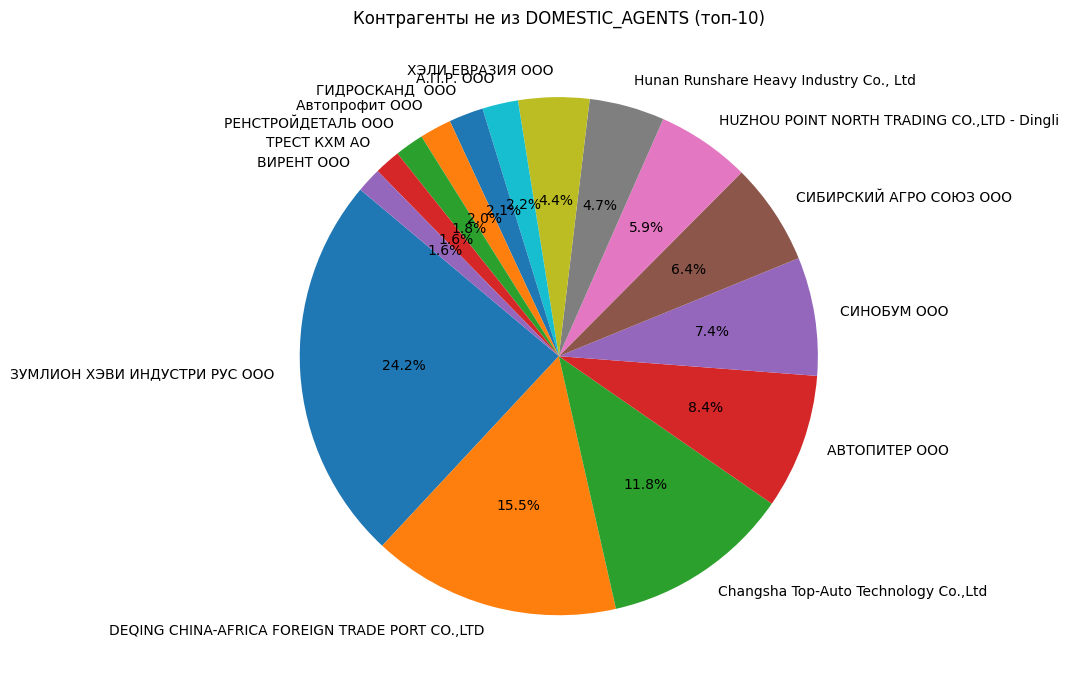

In [49]:
import matplotlib.pyplot as plt


DOMESTIC_COMPANIES = ['ЛК СПЕКТР', 'МЕГА МАШИНЕРИ', 'АК ФОРЛИФТ ООО', "БЕСТ ТЕХСЕРВИС", "ЙЕЛ РУС ООО"]

s = df1['Контрагент']
filtered = s[~s.str.upper().isin(DOMESTIC_COMPANIES)].value_counts().dropna()

top = filtered.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(top, labels=top.index, autopct='%1.1f%%', startangle=140)
ax.set_title('Контрагенты не из DOMESTIC_AGENTS (топ-10)')
plt.tight_layout()
plt.show()

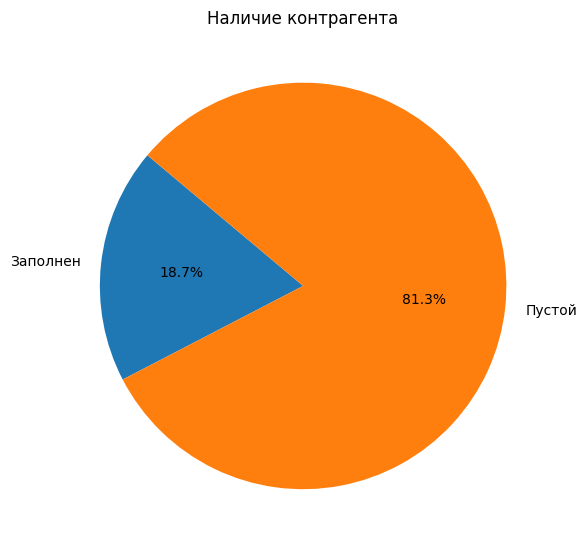

In [52]:
import matplotlib.pyplot as plt

counts = df1['Контрагент'].isna().value_counts()
labels = ['Заполнен', 'Пустой']
values = [counts.get(False, 0), counts.get(True, 0)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
ax.set_title('Наличие контрагента')
plt.tight_layout()
plt.show()

In [39]:
df1[df1['Номенклатура'] == "Гидронасос 1010001908"]

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток
2006,NaN,2023-10-23 12:28:46,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Поступление товаров и услуг ЛКС00010396 от 23....,"Changsha Top-Auto Technology Co.,Ltd",0.0,2.0,0.0,2.0
2153,NaN,2023-11-07 10:05:17,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Перемещение товаров ЛКС00012779 от 07.11.2023 ...,NaN,2.0,2.0,2.0,2.0
2308,NaN,2023-11-16 15:55:29,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Расходный ордер на товары БТС00016874 от 16.11...,NaN,2.0,0.0,1.0,1.0
2310,NaN,2023-11-16 15:55:32,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Приходный ордер на товары БТС00016046 от 16.11...,NaN,1.0,1.0,0.0,2.0
2412,NaN,2023-11-21 17:41:04,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Приходный ордер на товары ЛКС00014080 от 21.11...,ЗУМЛИОН ХЭВИ ИНДУСТРИ РУС ООО,2.0,1.0,0.0,3.0
2414,NaN,2023-11-22 10:21:11,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Расходный ордер на товары ЛКС00013353 от 22.11...,NaN,3.0,0.0,1.0,2.0
2430,NaN,2023-11-23 16:29:52,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Приходный ордер на товары ЛКС00014212 от 23.11...,NaN,2.0,1.0,0.0,3.0
2501,NaN,2023-11-29 16:00:30,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Списание товаров в ремонт ЛКС02096 от 29.11.20...,NaN,3.0,0.0,1.0,2.0
2564,NaN,2023-12-04 13:20:00,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Требование-накладная ЛКС00000804 от 04.12.2023...,NaN,2.0,0.0,1.0,1.0
2571,NaN,2023-12-04 13:20:01,Гидронасос 1010001908,1010001908,1010001908,Я0383576,Корректировка записей регистров 00000002055 от...,NaN,1.0,0.0,-1.0,2.0


In [ ]:
DOMESTIC_COMPANIES = ['ЛК СПЕКТР', 'Мега Машинери', 'АК ФОРЛИФТ ООО', "БЕСТ ТЕХСЕРВИС", "ЙЕЛ РУС ООО"]

In [34]:
df1['Период'] = pd.to_datetime(df1['Период'], dayfirst=True, errors='coerce')

for col in ["Расход", "Приход", "Конечный остаток", "Начальный остаток"]:
    df1[col] = pd.to_numeric(
    df1[col].astype(str).str.replace(' ', '').str.replace(',', '.'),
    errors='coerce')
    # df.loc[df[col] < 0, col] = 0
    
    if col != 'Конечный остаток':
        df1[col] = df1[col].fillna(0)

mask = df1["Конечный остаток"].isna()
df1.loc[mask, "Конечный остаток"] = (
    df1.loc[mask, "Начальный остаток"]
    + df1.loc[mask, "Приход"]
    - df1.loc[mask, "Расход"]
)

In [36]:
df1[df1['Номенклатура'] == "Фильтр воздушный комплект AF2555+AF25484"][:60]

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток
26004,NaN,2025-07-23 05:08:41,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Приходный ордер на товары ЛКС00026533 от 23.07...,ОЙЛ ГРУПП ООО,0.0,10.0,0.0,10.0
26010,NaN,2025-07-23 05:10:10,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Приходный ордер на товары ЛКС00026532 от 23.07...,ОЙЛ ГРУПП ООО,10.0,10.0,0.0,20.0
26703,NaN,2025-07-30 11:21:24,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Расходный ордер на товары ЛКС00025481 от 30.07...,NaN,20.0,0.0,1.0,19.0
26704,NaN,2025-07-30 11:21:26,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Приходный ордер на товары ЛКС00027826 от 30.07...,NaN,19.0,1.0,0.0,20.0
27113,NaN,2025-08-04 13:23:47,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Списание товаров в ремонт ЛКС08390 от 04.08.20...,NaN,20.0,0.0,1.0,19.0
27450,NaN,2025-08-08 10:54:53,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Расходный ордер на товары ЛКС00027126 от 08.08...,NaN,19.0,0.0,20.0,-1.0
27465,NaN,2025-08-08 10:54:59,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Приходный ордер на товары ЛКС00029633 от 08.08...,NaN,-1.0,20.0,0.0,19.0
45576,NaN,2026-01-16 04:18:15,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Расходный ордер на товары ЛКС00001340 от 16.01...,NaN,19.0,0.0,1.0,18.0
45579,NaN,2026-01-16 04:18:19,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Приходный ордер на товары ЛКС00001441 от 16.01...,NaN,18.0,1.0,0.0,19.0
46332,NaN,2026-01-20 14:14:06,Фильтр воздушный комплект AF2555+AF25484,2555,1000100310+1000100311,Я0402018,Списание товаров в ремонт ЛКС00841 от 20.01.20...,NaN,19.0,0.0,1.0,18.0


In [ ]:
df[df['Контрагент'] == "Любаев Олег Владимирович"] "Пахтусов Юрий Викторович" "Соколенко Ирина Владимировна" "Чигринов Алексей Владимирович" "Арутюнян Эрикназ Гамлетовна"
df[df['Контрагент'] == "БЕСТ ТЕХСЕРВИС"]
df[df['Контрагент'] == "ЙЕЛ РУС ООО"]

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток
711,NaN,2023-05-24 12:55:07,"Обогреватель предпусковой Северс+ Премиум 2,0кВт.","Северс+ Премиум 2,0",00078886,Я0379172,Расходный ордер на товары ЛКС00004570 от 24.05...,ЙЕЛ РУС ООО,7.0,0.0,1.0,6.0


In [ ]:
df[df['Контрагент'].str.lower().str.startswith('Списание', na=False)]

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток


In [ ]:
df = df.iloc[:-1]
df['Период'] = pd.to_datetime(df['Период'], format='%d.%m.%Y %H:%M:%S')
df.loc[:, 'Год'] = df['Период'].dt.year
df.loc[:, 'Месяц'] = df['Период'].dt.month
df

,Unnamed: 0,Период,Номенклатура,Артикул,Оригинальный номер,Код,Документ движения (Регистратор),Контрагент,Начальный остаток,Приход,Расход,Конечный остаток,Год,Месяц
0,NaN,2023-01-01 00:00:00,Фильтр воздушный P775298 внутренний,2740538,4000211720,Я0375774,NaN,NaN,4.0,0.0,0.0,4.0,2023,1
1,NaN,2023-01-01 00:00:00,Выключатель концевой 1020520944,1020520944,1020520944,Я0376635,NaN,NaN,4.0,0.0,0.0,4.0,2023,1
2,NaN,2023-01-01 00:00:00,Выключатель концевой 0077110ECN1000001,0077110ECN1000001,0077110ECN1000001,Я0376636,NaN,NaN,4.0,0.0,0.0,4.0,2023,1
3,NaN,2023-01-01 00:00:00,Выключатель 1020304979,1020304979,1020304979,Я0376637,NaN,NaN,2.0,0.0,0.0,2.0,2023,1
4,NaN,2023-01-01 00:00:00,Устройство зарядное 1022306253,1022306253,1022306253,Я0376639,NaN,NaN,1.0,0.0,0.0,1.0,2023,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62264,NaN,2026-04-02 23:59:59,Датчик колеса\t1021407359,1021407359,1021407359,Я0401856,NaN,NaN,1.0,0.0,0.0,1.0,2026,4
62265,NaN,2026-04-02 23:59:59,Клапан рулевой R0G24-10201A,R0G24-10201A,R0G24-10201A,Я0401857,NaN,NaN,1.0,0.0,0.0,1.0,2026,4
62266,NaN,2026-04-02 23:59:59,Бачок расширительный JCPT 10015262,10015262,10015262,Я0401873,NaN,NaN,1.0,0.0,0.0,1.0,2026,4
62267,NaN,2026-04-02 23:59:59,Преобразователь SD-305C-24,SD-305C-24,NaN,Я0401912,NaN,NaN,2.0,0.0,0.0,2.0,2026,4


In [1]:
from pathlib import Path
import sys

import openpyxl
import pandas as pd
from openpyxl.styles import PatternFill

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def project_path(path: str | Path) -> Path:
    path = Path(path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def _build_article_lookup(df1: pd.DataFrame) -> tuple[dict[str, int], dict[str, tuple[str, ...]]]:
    article_to_group: dict[str, int] = {}
    article_to_analogs_sets: dict[str, set[str]] = {}

    for _, row in df1.iterrows():
        group = row["Номер группы"]
        analogs = row["all_analogs"]
        if pd.isna(group) or not isinstance(analogs, tuple):
            continue

        forms_to_bind = set(analogs)
        main = row.get("Номенклатура.Артикул")
        if pd.notna(main) and main:
            forms_to_bind.add(main)

        for art in forms_to_bind:
            article_to_group[art] = int(group)
            article_to_analogs_sets.setdefault(art, set()).update(analogs)

    article_to_analogs = {
        art: tuple(sorted(analogs_set))
        for art, analogs_set in article_to_analogs_sets.items()
    }

    return article_to_group, article_to_analogs


GROUP_FILLS = [
    "FDE68A",
    "BFDBFE",
    "C7D2FE",
    "BBF7D0",
    "FBCFE8",
    "A7F3D0",
    "FECACA",
    "DDD6FE",
    "FED7AA",
    "E9D5FF",
]


from pipeline.runner import (
    _build_article_lookup,
    _drop_rows_without_identifiers,
    _enrich_analogs,
    _lookup_group,
    _sync_group_membership,
)
from preprocessing.cleaning import (
    fill_missing_article,
    normalize_nomenclatures_repair_parts,
    normalize_nomenclatures_stock_report,
)
from preprocessing.grouping import (
    build_analog_graph,
    consolidate_extended_article_numbers,
    find_all_analogs,
    normalize_analog_lists,
)
from preprocessing.normalization import article_forms, normalize
from readers.loaders import preprocess_repair_parts, preprocess_stock_report


def build_group_analogs_excel(
    repair_path: str | Path,
    stock_path: str | Path,
    output_path: str | Path = "data/processed/Аналоги.xlsx",
) -> pd.DataFrame:
    repair_path = project_path(repair_path)
    stock_path = project_path(stock_path)
    output_path = project_path(output_path)

    df1 = preprocess_repair_parts(str(repair_path))
    df1 = normalize_nomenclatures_repair_parts(df1)

    for col in [
        "Номенклатура.Артикул",
        "Номенклатура.Оригинальный номер",
        "Номенклатура.Оригинальный номер расширенный",
    ]:
        df1[col] = df1[col].apply(normalize)

    df1 = fill_missing_article(
        df1,
        "Номенклатура.Артикул",
        "Номенклатура.Оригинальный номер",
    )
    df1 = _drop_rows_without_identifiers(
        df1,
        "Номенклатура.Артикул",
        "Номенклатура.Оригинальный номер",
    )

    df1["Номенклатура.Оригинальный номер расширенный"] = df1.apply(
        consolidate_extended_article_numbers,
        axis=1,
    )
    df1["Аналоги"] = (
        df1["Номенклатура.Оригинальный номер расширенный"]
        .fillna("")
        .str.upper()
        .str.split()
    )

    graph = build_analog_graph(df1)
    df1["all_analogs"] = df1["Номенклатура.Артикул"].apply(
        lambda x: find_all_analogs(x, graph)
    )
    df1 = df1.drop(columns="Аналоги")

    group_mapping = {
        analog_tuple: idx
        for idx, analog_tuple in enumerate(df1["all_analogs"].unique(), start=1)
    }
    df1["Номер группы"] = df1["all_analogs"].apply(group_mapping.get).astype("Int64")

    df2 = preprocess_stock_report(str(stock_path))
    df2 = normalize_nomenclatures_stock_report(df2)
    df2["Артикул"] = df2["Артикул"].apply(normalize)
    df2["Оригинальный номер"] = df2["Оригинальный номер"].apply(normalize)
    df2 = fill_missing_article(df2, "Артикул", "Оригинальный номер")
    df2 = _drop_rows_without_identifiers(df2, "Артикул", "Оригинальный номер")

    article_to_group, article_to_analogs = _build_article_lookup(df1)

    groups, analogs_list = zip(
        *df2.apply(
            lambda r: _lookup_group(
                r["Артикул"],
                r["Оригинальный номер"],
                article_to_group,
                article_to_analogs,
            ),
            axis=1,
        )
    )
    df2["Номер группы"] = pd.Series(groups, index=df2.index, dtype="Int64")
    df2["Список аналогов"] = analogs_list

    df2["Список аналогов"] = df2.apply(
        lambda r: _enrich_analogs(r, article_to_group),
        axis=1,
    )
    df2 = normalize_analog_lists(df2)

    df1, df2 = _sync_group_membership(df1, df2)
    article_to_group, article_to_analogs = _build_article_lookup(df1)

    unmatched_idx = df2[df2["Номер группы"].isna()].index
    relinked_idx = []

    for idx in unmatched_idx:
        grp, analogs = _lookup_group(
            normalize(df2.at[idx, "Артикул"]),
            normalize(df2.at[idx, "Оригинальный номер"]),
            article_to_group,
            article_to_analogs,
        )
        if grp is None:
            continue

        df2.at[idx, "Номер группы"] = grp
        df2.at[idx, "Список аналогов"] = analogs
        relinked_idx.append(idx)

    if relinked_idx:
        df2.loc[relinked_idx, "Список аналогов"] = (
            df2.loc[relinked_idx]
            .apply(lambda r: _enrich_analogs(r, article_to_group), axis=1)
        )
        df2 = normalize_analog_lists(df2)
        df1, df2 = _sync_group_membership(df1, df2)
        article_to_group, article_to_analogs = _build_article_lookup(df1)

    graph_new = {}
    graph_new = __import__("collections").defaultdict(set)
    unmatched_idx = df2[df2["Номер группы"].isna()].index

    for idx in unmatched_idx:
        art = normalize(df2.at[idx, "Артикул"])
        orig = normalize(df2.at[idx, "Оригинальный номер"])

        if art is None:
            if orig is not None:
                art = orig
            else:
                continue

        all_forms = article_forms(art) + (article_forms(orig) if orig else [])
        if any(f in article_to_group for f in all_forms):
            continue

        for af in article_forms(art):
            for bf in article_forms(art):
                if af != bf:
                    graph_new[af].add(bf)
                    graph_new[bf].add(af)

        if orig is not None:
            for af in article_forms(art):
                for bf in article_forms(orig):
                    if af != bf:
                        graph_new[af].add(bf)
                        graph_new[bf].add(af)

    for idx in unmatched_idx:
        art = normalize(df2.at[idx, "Артикул"])
        orig = normalize(df2.at[idx, "Оригинальный номер"])
        if art is None:
            art = orig

        all_forms = article_forms(art) if art else []
        if any(f in article_to_group for f in all_forms):
            continue

        df2.at[idx, "Список аналогов"] = (
            find_all_analogs(art, graph_new) if art is not None else tuple()
        )

    unique_new = (
        df2.loc[df2["Номер группы"].isna(), "Список аналогов"]
        .drop_duplicates()
    )
    new_group_start = int(df1["Номер группы"].max()) + 1
    new_group_map = {
        grp: new_group_start + i
        for i, grp in enumerate(unique_new)
    }
    mask_new = df2["Номер группы"].isna()
    df2.loc[mask_new, "Номер группы"] = df2.loc[mask_new, "Список аналогов"].apply(
        lambda x: new_group_map.get(x)
    )
    df2["Номер группы"] = df2["Номер группы"].astype("Int64")
    df2 = normalize_analog_lists(df2)

    repair_members = df1[[
        "Номер группы",
        "Номенклатура.Артикул",
        "Номенклатура.Оригинальный номер",
        "Номенклатура.Оригинальный номер расширенный",
        "Номенклатура",
        "all_analogs",
    ]].rename(columns={
        "Номенклатура.Артикул": "Артикул",
        "Номенклатура.Оригинальный номер": "Оригинальный номер",
        "Номенклатура.Оригинальный номер расширенный": "Оригинальный номер расширенный",
        "all_analogs": "Список аналогов",
    })

    stock_members = df2[[
        "Номер группы",
        "Артикул",
        "Оригинальный номер",
        "Номенклатура",
        "Список аналогов",
    ]]
    stock_members["Оригинальный номер расширенный"] = pd.NA

    members = pd.concat([repair_members, stock_members], ignore_index=True)
    members = members[members["Номер группы"].notna()].copy()
    members["Номер группы"] = members["Номер группы"].astype(int)
    members = normalize_analog_lists(members)

    members["Артикул_key"] = (
        members["Артикул"].astype("string").str.strip().replace("", pd.NA)
    )
    members["Оригинальный номер_key"] = (
        members["Оригинальный номер"].astype("string").str.strip().replace("", pd.NA)
    )
    members["Оригинальный номер расширенный_key"] = (
        members["Оригинальный номер расширенный"].astype("string").str.strip().replace("", pd.NA)
    )
    members["Номенклатура_key"] = (
        members["Номенклатура"].astype("string").str.strip().replace("", pd.NA)
    )

    group_stats = (
        members.groupby("Номер группы", as_index=False)
        .agg(
            unique_articles=("Артикул_key", lambda s: s.dropna().nunique()),
            unique_original_numbers=("Оригинальный номер_key", lambda s: s.dropna().nunique()),
            unique_extended_original_numbers=("Оригинальный номер расширенный_key", lambda s: s.dropna().nunique()),
            unique_nomenclatures=("Номенклатура_key", lambda s: s.dropna().nunique()),
        )
    )

    valid_groups = group_stats.loc[
        (group_stats["unique_articles"] > 1)
        | (group_stats["unique_original_numbers"] > 1)
        | (group_stats["unique_extended_original_numbers"] > 1)
        | (group_stats["unique_nomenclatures"] > 1),
        "Номер группы",
    ]
    members = members[members["Номер группы"].isin(valid_groups)].copy()

    distinct_members = members.drop_duplicates(
        subset=[
            "Номер группы",
            "Артикул_key",
            "Оригинальный номер_key",
            "Оригинальный номер расширенный_key",
            "Номенклатура_key",
        ],
        keep="first",
    ).copy()

    full_analogs_map = (
        members.groupby("Номер группы")["Список аналогов"]
        .agg(
            lambda s: max(
                (v for v in s.dropna() if isinstance(v, tuple)),
                key=len,
                default=tuple(),
            )
        )
        .to_dict()
    )

    export_df = distinct_members[[
        "Номер группы",
        "Артикул",
        "Оригинальный номер",
        "Оригинальный номер расширенный",
        "Номенклатура",
    ]].copy()
    export_df["Список аналогов"] = export_df["Номер группы"].map(
        lambda group_id: " ".join(full_analogs_map.get(group_id, tuple()))
    )
    export_df = export_df.sort_values(
        [
            "Номер группы",
            "Артикул",
            "Оригинальный номер",
            "Оригинальный номер расширенный",
            "Номенклатура",
        ],
        kind="stable",
    ).reset_index(drop=True)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    export_df.to_excel(output_path, index=False)

    workbook = openpyxl.load_workbook(output_path)
    worksheet = workbook.active
    group_colors = {
        group_id: GROUP_FILLS[idx % len(GROUP_FILLS)]
        for idx, group_id in enumerate(export_df["Номер группы"].drop_duplicates())
    }

    for row_idx, group_id in enumerate(export_df["Номер группы"], start=2):
        fill = PatternFill(fill_type="solid", fgColor=group_colors[group_id])
        for col_idx in range(1, worksheet.max_column + 1):
            worksheet.cell(row=row_idx, column=col_idx).fill = fill

    workbook.save(output_path)

    return export_df


export_df = build_group_analogs_excel(
    repair_path = r"C:\Users\a.vorona\Desktop\Forecast\data\raw\Запчасти списанные в ремонт_22_04_26.xlsx",
    stock_path = r"C:\Users\a.vorona\Desktop\Forecast\data\raw\Остатки и обороты_22_04_2026.xlsx",
    output_path = "data/processed/Аналоги.xlsx",
)

export_df.head(20)

c:\Users\a.vorona\Desktop\Forecast\preprocessing\cleaning.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ].str.contains(
c:\Users\a.vorona\Desktop\Forecast\preprocessing\cleaning.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ].str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_5952\1157916297.py:276: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_members["Оригинальный номер расширенный"] = pd.NA


,Номер группы,Артикул,Оригинальный номер,Оригинальный номер расширенный,Номенклатура,Список аналогов
0,1,A21B4-32081,A21B4-32081,None,Рулевая серьга A21B4-32081,A21B4-32081
1,1,A21B4-32081,A21B4-32081,NaN,Тяга рулевая (FD20-40),A21B4-32081
2,2,1351230500,1351230500,K127260-1-1,Фильтр воздушный (250*127*75) 1351230500,1351230500 13988768 1451230500 25591-00901 255...
3,2,1351230500,1351230500,NaN,Фильтр воздушный (250*127*75) 1351230500,1351230500 13988768 1451230500 25591-00901 255...
4,2,1451230500,1451230500,A408446 K127260,Фильтр воздушный UN 4-5t (280*127*75) A408446 ...,1351230500 13988768 1451230500 25591-00901 255...
5,2,1451230500,1451230500,NaN,Фильтр воздушный UN 4-5t (280*127*75) A408446 ...,1351230500 13988768 1451230500 25591-00901 255...
6,2,2559100901X,KW1025,25591-00901X KW1025,Фильтр воздушный 2559100901X,1351230500 13988768 1451230500 25591-00901 255...
7,2,2559100901X,KW1025,NaN,Фильтр воздушный 2559100901X,1351230500 13988768 1451230500 25591-00901 255...
8,2,A408446,A408446,NaN,Фильтр воздушный A408446,1351230500 13988768 1451230500 25591-00901 255...
9,2,H3QA100501X1,H3QA1-00601A,NaN,"Фильтр воздушный H3QA1-00501X-1 (H=365, D=153....",1351230500 13988768 1451230500 25591-00901 255...


In [ ]:
from pipeline.runner import run_full_pipeline

df = run_full_pipeline(r"C:\Users\a.vorona\Desktop\Forecast\data\raw\Запчасти списанные в ремонт_30_03_26_ПО_ПТО_ДСТ.xlsx", r"C:\Users\a.vorona\Desktop\Forecast\data\raw\Остатки и обороты_30_03_26_ПО_ПТО_ДСТ.xlsx")

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

groups_sorted = (
    export_df.groupby("Номер группы")["Артикул"]
    .count()
    .sort_values(ascending=False)
    .index
)

for group_id in groups_sorted[:13]:
    group_df = export_df[export_df["Номер группы"] == group_id]

    G = nx.Graph()

    for _, row in group_df.iterrows():
        art = row["Артикул"]
        orig = row["Оригинальный номер"]
        ext  = row["Оригинальный номер расширенный"]

        if art:
            G.add_node(art)

        # прямая связь артикул ↔ оригинальный номер
        if art and pd.notna(orig) and orig and orig != art:
            G.add_edge(art, orig)

        # связи через расширенный номер
        if art and pd.notna(ext):
            for linked in str(ext).split():
                if linked and linked != art:
                    G.add_edge(art, linked)

    if G.number_of_edges() == 0:
        continue

    # изолированные и связанные — разные цвета
    isolated = set(nx.isolates(G))
    node_colors = ["#FCA5A5" if n in isolated else "#BFDBFE" for n in G.nodes()]

    plt.figure(figsize=(15, 15))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color="#3B82F6",
        node_size=2000,
        font_size=7,
        font_color="#1E293B",
        width=2.0,
        alpha=0.9,
    )
    plt.title(
        f"Группа {group_id} — {G.number_of_nodes()} узлов, "
        f"{G.number_of_edges()} связей  |  красные = без связей"
    )
    plt.tight_layout()
    plt.show()